In [47]:
#lab7
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Thien

img = cv.imread('hinh1.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)


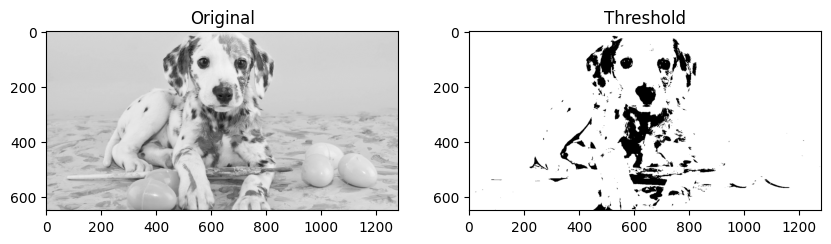

In [48]:

_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

Thien.figure(figsize=(10,4))
Thien.subplot(1,2,1)
Thien.imshow(gray, cmap='gray')
Thien.title("Original")

Thien.subplot(1,2,2)
Thien.imshow(thresh, cmap='gray')
Thien.title("Threshold")
Thien.show()


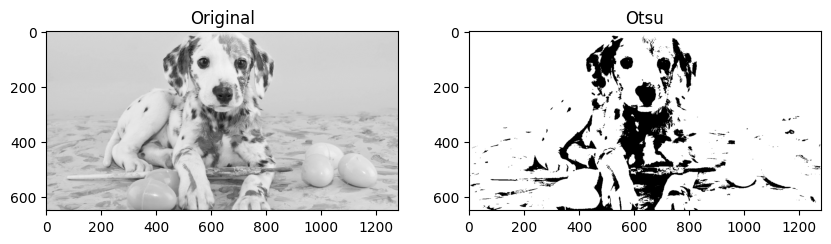

In [49]:

_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Thien.figure(figsize=(10,4))
Thien.subplot(1,2,1)
Thien.imshow(gray, cmap='gray')
Thien.title("Original")

Thien.subplot(1,2,2)
Thien.imshow(otsu, cmap='gray')
Thien.title("Otsu")
Thien.show()


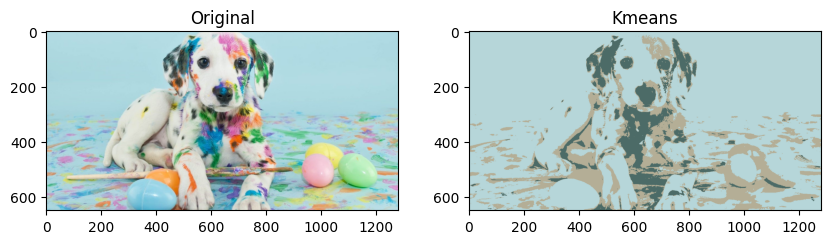

In [50]:

pixel_values = img.reshape((-1,3))
pixel_values = np.float32(pixel_values)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3

_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented = centers[labels.flatten()]
segmented = segmented.reshape(img.shape)

Thien.figure(figsize=(10,4))
Thien.subplot(1,2,1)
Thien.imshow(img)
Thien.title("Original")

Thien.subplot(1,2,2)
Thien.imshow(segmented)
Thien.title("Kmeans")
Thien.show()


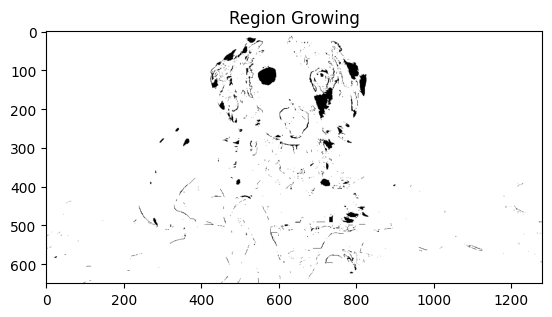

In [51]:

seed = (100,100)
visited = np.zeros(gray.shape, np.uint8)
region = np.zeros(gray.shape, np.uint8)

threshold = 10
stack = [seed]

while stack:
    x,y = stack.pop()
    if visited[x,y] == 0:
        visited[x,y] = 1
        region[x,y] = 255

        for i in range(-1,2):
            for j in range(-1,2):
                nx = x+i
                ny = y+j
                if nx>=0 and ny>=0 and nx<gray.shape[0] and ny<gray.shape[1]:
                    if visited[nx,ny]==0:
                        if abs(int(gray[nx,ny]) - int(gray[x,y])) < threshold:
                            stack.append((nx,ny))

Thien.imshow(region, cmap='gray')
Thien.title("Region Growing")
Thien.show()


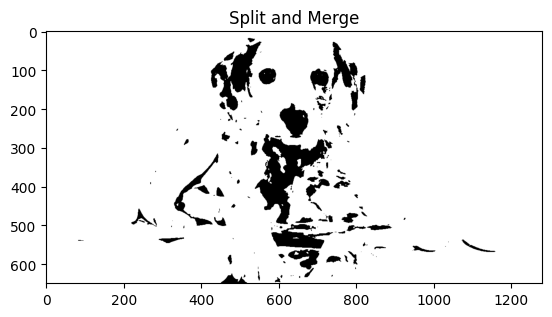

In [52]:

blur = cv.GaussianBlur(gray,(5,5),0)
_, split = cv.threshold(blur, 127,255,cv.THRESH_BINARY)

Thien.imshow(split, cmap='gray')
Thien.title("Split and Merge")
Thien.show()


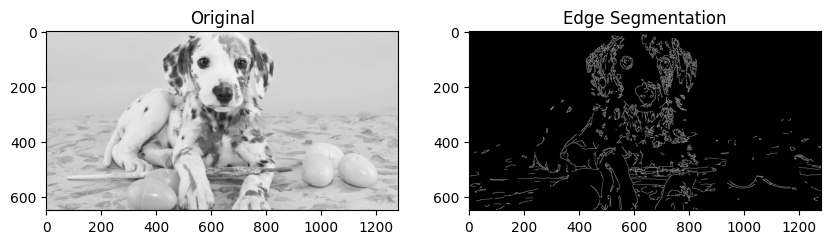

In [53]:

edges = cv.Canny(gray,100,200)

Thien.figure(figsize=(10,4))
Thien.subplot(1,2,1)
Thien.imshow(gray, cmap='gray')
Thien.title("Original")

Thien.subplot(1,2,2)
Thien.imshow(edges, cmap='gray')
Thien.title("Edge Segmentation")
Thien.show()


In [62]:
from imageai.Detection import VideoObjectDetection
import os

execution_path = os.getcwd()

detector = VideoObjectDetection()
detector.setModelTypeAsRetinaNet()

detector.setModelPath(
    os.path.join(execution_path, "retinanet_resnet50_fpn_coco-eeacb38b.pth")
)

detector.loadModel()

video_path = detector.detectObjectsFromVideo(
    input_file_path=os.path.join(execution_path, "video_predetect.mp4"),
    output_file_path=os.path.join(execution_path, "video_detected"),
    frames_per_second=5,
    log_progress=True
)

print("VIDEO PATH:", video_path)

VIDEO PATH: /content/video_detected.mp4
